# Seeds Dataset Clustering using DBSCAN

This project applies DBSCAN, a density based clustering algorithm, to group wheat grain varieties based on physical measurements such as area, perimeter, compactness, length, and width. Unlike K-Means, DBSCAN automatically determines the number of clusters and identifies grains with unusual measurements as noise, without requiring any predefined labels.

In [138]:
#Step 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [139]:
#Step 2
columns = ['Area', 'Perimeter', 'Compactness', 'Length', 'Width', 'Asymmetry', 'Groove_Length', 'Variety']
df = pd.read_csv('seeds_dataset.txt', sep='\t', names=columns)
df.head()


,Area,Perimeter,Compactness,Length,Width,Asymmetry,Groove_Length,Variety
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [140]:
#Step 3
df.shape

(210, 8)

In [141]:
#Step 4
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Area           210 non-null    float64
 1   Perimeter      210 non-null    float64
 2   Compactness    210 non-null    float64
 3   Length         210 non-null    float64
 4   Width          210 non-null    float64
 5   Asymmetry      210 non-null    float64
 6   Groove_Length  210 non-null    float64
 7   Variety        210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


In [142]:
#Step 5
#Select Relevant Features
X=df[['Area', 'Perimeter', 'Compactness', 'Length', 'Width', 'Asymmetry','Variety']]

In [143]:
#Step 6
sc=StandardScaler()
X_Scaled=sc.fit_transform(X)

In [144]:
#Step 7
min_samples=5

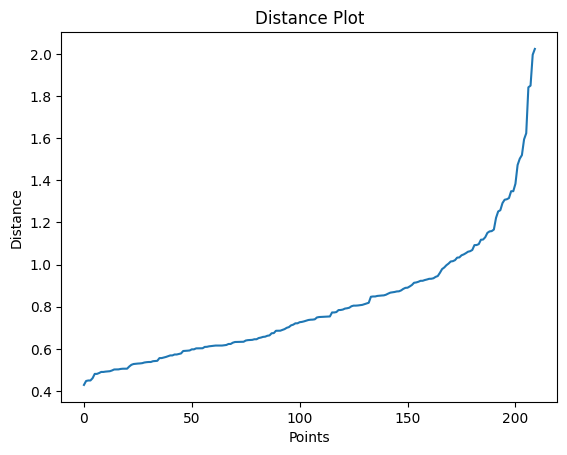

In [145]:
#Step 8
neighbors=NearestNeighbors(n_neighbors=min_samples)
neighbors_fit=neighbors.fit(X_Scaled)
distances,indices=neighbors_fit.kneighbors(X_Scaled)
distances=np.sort(distances[:,min_samples-1])
plt.plot(distances)
plt.xlabel("Points")
plt.ylabel('Distance')
plt.title('Distance Plot')
plt.show()


In [146]:
#Step 9
#Chossing best eps value
#Kneed Library
!pip install kneed
from kneed import KneeLocator
kneedle = KneeLocator(range(len(distances)), distances, curve='convex', direction='increasing')
eps_value = distances[kneedle.elbow]
print(f"Suggested eps: {eps_value}")

Suggested eps: 1.0974171991853077


In [147]:
#Step 10
dbscan=DBSCAN(eps=1.097,min_samples=5)
clusters=dbscan.fit_predict(X_Scaled)

In [148]:
#Step 11
df["cluster"]=clusters
df["cluster"].value_counts()

,count
cluster,
2,68
0,65
1,65
-1,12


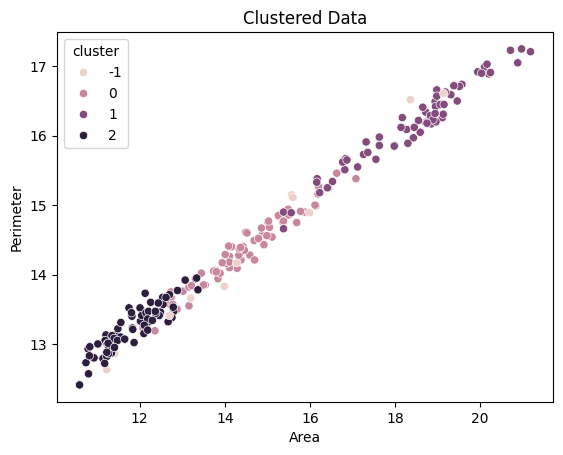

In [149]:
#Step 12
sns.scatterplot(x=df["Area"],y=df["Perimeter"],hue=df["cluster"])
plt.title('Clustered Data')
plt.show()

In [150]:
#Step 13
df.groupby('cluster')[['Area', 'Perimeter', 'Compactness', 'Length','Variety']].mean()

,Area,Perimeter,Compactness,Length,Variety
cluster,,,,,
-1,14.465833,14.359167,0.876200,5.503667,1.75
0,14.467385,14.363692,0.880011,5.538138,1.00
1,18.442154,16.172615,0.884795,6.158800,2.00
2,11.842206,13.239412,0.848278,5.230103,3.00


## Conclusion

In this project, DBSCAN clustering was applied to the Seeds dataset to group wheat grains based on their physical characteristics. The data was standardized before clustering, and the `eps` value was selected using a distance plot and the KneeLocator method.Overall, this project demonstrates how DBSCAN can discover groups in data without predefined class labels and can also identify observations that do not belong to dense clusters.
